<a href="https://colab.research.google.com/github/jojoadv77-sketch/SDP2_code/blob/main/cyberbullying_detection_13_3_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cyberbullying Detection using BERTweet
This notebook trains a BERTweet model to classify tweets into 6 categories:
- not_cyberbullying
- gender
- religion
- other_cyberbullying
- age
- ethnicity

## Cell 1: Install and Import Libraries

In [2]:
!pip install transformers torch emoji pandas scikit-learn seaborn matplotlib -q

import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import emoji
import json
from torch import nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from collections import defaultdict

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 13.8 MB/s eta 0:00:00
Running on: cuda:0


###Cell 1.5 :Emoji2vec files


In [3]:
!pip install transformers torch emoji pandas scikit-learn seaborn matplotlib -q
!pip install gensim -q  # gensim loads emoji2vec
# Download pretrained emoji2vec embeddings
!wget -q https://github.com/uclnlp/emoji2vec/raw/master/pre-trained/emoji2vec.bin
import gensim
# Load emoji2vec
e2v = gensim.models.KeyedVectors.load_word2vec_format('emoji2vec.bin', binary=True)
print(f"✅ emoji2vec loaded! Vocabulary size: {len(e2v)} emojis")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 54.9 MB/s eta 0:00:00
✅ emoji2vec loaded! Vocabulary size: 1661 emojis




```
# This is formatted as code
```

###Cell 1.6: EmojiEncoder Class for DAM

In [4]:
class DualAttentionModule(nn.Module):
    def __init__(self, e2v, embed_dim=300, hidden_dim=768):
        super(DualAttentionModule, self).__init__()
        self.e2v = e2v
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim

        # Project emoji from 300 -> 768 to match BERT
        self.emoji_projection = nn.Linear(embed_dim, hidden_dim)
        self.relu = nn.ReLU()

        # --- Intramodal Attention ---
        # Text attending to itself
        self.text_intra_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=8,
            batch_first=True
        )
        # Emoji attending to itself
        self.emoji_intra_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=8,
            batch_first=True
        )

        # --- Intermodal Attention ---
        # Text attending to emoji
        self.text_inter_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=8,
            batch_first=True
        )
        # Emoji attending to text
        self.emoji_inter_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=8,
            batch_first=True
        )

        # Final fusion layer: combines all 4 attention outputs
        # 4 x 768 = 3072 -> 768
        self.fusion = nn.Linear(hidden_dim * 4, hidden_dim)

    def forward(self, text_features, emoji_vectors):
        # text_features shape:  (batch_size, 768)   <- BERT pooled output
        # emoji_vectors shape:  (batch_size, 300)   <- raw emoji2vec

        # Step 1: Project emoji to 768
        emoji_features = self.relu(self.emoji_projection(emoji_vectors))
        # emoji_features shape: (batch_size, 768)

        # MultiheadAttention expects (batch, seq_len, features)
        # We treat each as a sequence of length 1
        text_seq = text_features.unsqueeze(1)    # (batch, 1, 768)
        emoji_seq = emoji_features.unsqueeze(1)  # (batch, 1, 768)

        # Step 2: Intramodal Attention
        # Text attending to itself
        text_intra, _ = self.text_intra_attn(
            query=text_seq,
            key=text_seq,
            value=text_seq
        )  # (batch, 1, 768)

        # Emoji attending to itself
        emoji_intra, _ = self.emoji_intra_attn(
            query=emoji_seq,
            key=emoji_seq,
            value=emoji_seq
        )  # (batch, 1, 768)

        # Step 3: Intermodal Attention
        # Text attending to emoji (text queries, emoji keys/values)
        text_inter, _ = self.text_inter_attn(
            query=text_seq,
            key=emoji_seq,
            value=emoji_seq
        )  # (batch, 1, 768)

        # Emoji attending to text (emoji queries, text keys/values)
        emoji_inter, _ = self.emoji_inter_attn(
            query=emoji_seq,
            key=text_seq,
            value=text_seq
        )  # (batch, 1, 768)

        # Step 4: Squeeze sequence dimension and concatenate all 4
        text_intra = text_intra.squeeze(1)    # (batch, 768)
        emoji_intra = emoji_intra.squeeze(1)  # (batch, 768)
        text_inter = text_inter.squeeze(1)    # (batch, 768)
        emoji_inter = emoji_inter.squeeze(1)  # (batch, 768)

        # Fuse: concat all 4 -> (batch, 3072) -> linear -> (batch, 768)
        fused = torch.cat([text_intra, emoji_intra, text_inter, emoji_inter], dim=1)
        output = self.fusion(fused)  # (batch, 768)

        return output


def get_emoji_vector(emoji_list, e2v, embed_dim=300):
    vectors = []
    for e in emoji_list:
        if e in e2v:
            vectors.append(e2v[e])
    if vectors:
        return np.mean(vectors, axis=0).astype(np.float32)
    else:
        return np.zeros(embed_dim, dtype=np.float32)


# Quick test
test = get_emoji_vector(['😊', '🤮'], e2v)
print(f"Emoji vector shape: {test.shape}")   # Should print (300,)
print(f"All zeros? {np.all(test == 0)}")     # Should print False

Emoji vector shape: (300,)
All zeros? False


Cell 1.7: Load cardiffnlp/twitter-roberta-base-irony sarcasm model

In [5]:
# Load a pretrained sarcasm detector from HuggingFace
# This model was trained on tweets so it matches your data
from transformers import pipeline

sarcasm_detector = pipeline(
    "text-classification",
    model="cardiffnlp/twitter-roberta-base-irony",
    device=0 if torch.cuda.is_available() else -1
)

def get_sarcasm_score(text):
    result = sarcasm_detector(text, truncation=True, max_length=128)
    # Returns label LABEL_1 = ironic/sarcastic, LABEL_0 = not
    if result[0]['label'] == 'LABEL_1':
        return result[0]['score']  # confidence it IS sarcastic
    else:
        return 1 - result[0]['score']  # flip to get sarcasm probability

# Test it
print(get_sarcasm_score("Oh great, another Monday 🙄"))   # should be high
print(get_sarcasm_score("Have a wonderful day! 😊"))      # should be low

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/705 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-irony
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

0.0365602970123291
0.3405011296272278


## Cell 2: Load Dataset

In [6]:
from google.colab import files
import io

print("Upload cyberbullying_tweets.csv:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))
print(f"✅ Loaded {len(df)} rows")
print(df.head())

Upload cyberbullying_tweets.csv:


Saving cyberbullying_tweets.csv to cyberbullying_tweets.csv
✅ Loaded 47692 rows
                                          tweet_text cyberbullying_type
0  In other words #katandandre, your food was cra...  not_cyberbullying
1  Why is #aussietv so white? #MKR #theblock #ImA...  not_cyberbullying
2  @XochitlSuckkks a classy whore? Or more red ve...  not_cyberbullying
3  @Jason_Gio meh. :P  thanks for the heads up, b...  not_cyberbullying
4  @RudhoeEnglish This is an ISIS account pretend...  not_cyberbullying


## Cell 3: Compute sarcasm scores for all tweets

In [7]:
USE_EMOJIS = True

def process_text(text):
    text = str(text)
    if USE_EMOJIS:
        text = emoji.demojize(text, delimiters=(" ", " "))
        text = text.replace("_", " ").replace(":", "")
    else:
        text = emoji.replace_emoji(text, replace='')
    text = re.sub(r"http\S+|www\S+|https\S+", 'HTTPURL', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '@USER', text)
    return re.sub(r'\s+', ' ', text).strip()

df['emojis'] = df['tweet_text'].apply(lambda x: [e['emoji'] for e in emoji.emoji_list(str(x))])
df['content'] = df['tweet_text'].apply(process_text)

# ADD THIS: compute sarcasm score for every tweet
# Note: this will take a few minutes on 47k tweets
print("Computing sarcasm scores... (this takes a few minutes)")
df['sarcasm_score'] = df['tweet_text'].apply(
    lambda x: get_sarcasm_score(str(x)[:128])  # truncate for speed
)
print("✅ Sarcasm scores computed!")
print(df[['tweet_text', 'sarcasm_score']].head())

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Computing sarcasm scores... (this takes a few minutes)
✅ Sarcasm scores computed!
                                          tweet_text  sarcasm_score
0  In other words #katandandre, your food was cra...       0.358117
1  Why is #aussietv so white? #MKR #theblock #ImA...       0.099109
2  @XochitlSuckkks a classy whore? Or more red ve...       0.085776
3  @Jason_Gio meh. :P  thanks for the heads up, b...       0.465237
4  @RudhoeEnglish This is an ISIS account pretend...       0.045620


## Cell 4: Create Labels and Split Data
- Maps text labels to numbers (e.g. 'religion' -> 0, 'gender' -> 1)
- Splits data into 90% train, 5% validation, 5% test

In [8]:
# Map text labels to numbers
class_names = df['cyberbullying_type'].unique()
label_map = {name: i for i, name in enumerate(class_names)}
df['sentiment'] = df['cyberbullying_type'].map(label_map)

print("Classes:", class_names)
print("Label map:", label_map)
print("\nClass distribution:")
print(df['cyberbullying_type'].value_counts())

# Split into train (90%), val (5%), test (5%)
RANDOM_SEED = 42
df_train, df_test = train_test_split(df, test_size=0.1, random_state=RANDOM_SEED)
df_val, df_test = train_test_split(df_test, test_size=0.5, random_state=RANDOM_SEED)

print(f"\nTrain: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

Classes: ['not_cyberbullying' 'gender' 'religion' 'other_cyberbullying' 'age'
 'ethnicity']
Label map: {'not_cyberbullying': 0, 'gender': 1, 'religion': 2, 'other_cyberbullying': 3, 'age': 4, 'ethnicity': 5}

Class distribution:
cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64

Train: 42922, Val: 2385, Test: 2385


## Cell 5: Load BERTweet Tokenizer
BERTweet is a BERT model pre-trained on 850M English tweets

In [9]:
PRE_TRAINED_MODEL_NAME = 'vinai/bertweet-base'
tokenizer = AutoTokenizer.from_pretrained(PRE_TRAINED_MODEL_NAME, use_fast=False)
print("✅ BERTweet tokenizer loaded!")

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ BERTweet tokenizer loaded!


## Cell 6: Pass sarcasm scores into Dataset and DataLoader
- SentimentDataset converts raw text into tokenized tensors for the model
- DataLoader batches the data for efficient training

In [10]:
class SentimentDataset(Dataset):
    def __init__(self, reviews, targets, tokenizer, max_len, emoji_vectors, sarcasm_scores):
        self.reviews = reviews
        self.targets = targets
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.emoji_vectors = emoji_vectors
        self.sarcasm_scores = sarcasm_scores  # ADD THIS

    def __len__(self):
        return len(self.reviews)

    def __getitem__(self, item):
        review = str(self.reviews[item])
        target = self.targets[item]
        encoding = self.tokenizer(
            review,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'review_text': review,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'targets': torch.tensor(target, dtype=torch.long),
            'emoji_vector': torch.tensor(self.emoji_vectors[item], dtype=torch.float),
            'sarcasm_score': torch.tensor(self.sarcasm_scores[item], dtype=torch.float)  # ADD THIS
        }

BATCH_SIZE = 32
MAX_LEN = 128

train_emoji_vectors = np.array([get_emoji_vector(e, e2v) for e in df_train['emojis'].tolist()])
val_emoji_vectors   = np.array([get_emoji_vector(e, e2v) for e in df_val['emojis'].tolist()])
test_emoji_vectors  = np.array([get_emoji_vector(e, e2v) for e in df_test['emojis'].tolist()])

train_data_loader = DataLoader(
    SentimentDataset(
        df_train['content'].to_numpy(), df_train['sentiment'].to_numpy(),
        tokenizer, MAX_LEN, train_emoji_vectors,
        df_train['sarcasm_score'].to_numpy()  # ADD THIS
    ),
    batch_size=BATCH_SIZE, num_workers=0
)
val_data_loader = DataLoader(
    SentimentDataset(
        df_val['content'].to_numpy(), df_val['sentiment'].to_numpy(),
        tokenizer, MAX_LEN, val_emoji_vectors,
        df_val['sarcasm_score'].to_numpy()  # ADD THIS
    ),
    batch_size=BATCH_SIZE, num_workers=0
)
test_data_loader = DataLoader(
    SentimentDataset(
        df_test['content'].to_numpy(), df_test['sentiment'].to_numpy(),
        tokenizer, MAX_LEN, test_emoji_vectors,
        df_test['sarcasm_score'].to_numpy()  # ADD THIS
    ),
    batch_size=BATCH_SIZE, num_workers=0
)
print("✅ DataLoaders ready!")

✅ DataLoaders ready!


## Cell 7: Model concatenates sarcasm score with DAM output

In [11]:
class SentimentClassifier(nn.Module):
    def __init__(self, n_classes):
        super(SentimentClassifier, self).__init__()
        self.bert = AutoModel.from_pretrained(PRE_TRAINED_MODEL_NAME)
        self.dam = DualAttentionModule(e2v)
        self.drop = nn.Dropout(p=0.3)
        # DAM outputs 768, + 1 sarcasm score = 769
        self.out = nn.Linear(768 + 1, n_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, input_ids, attention_mask, emoji_vectors, sarcasm_scores):
        _, pooled_output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=False
        )
        fused = self.dam(pooled_output, emoji_vectors)
        output = self.drop(fused)
        # Append sarcasm score as extra feature
        sarcasm_scores = sarcasm_scores.unsqueeze(1)  # (batch,) -> (batch, 1)
        output = torch.cat([output, sarcasm_scores], dim=1)  # (batch, 769)
        output = self.out(output)
        return self.softmax(output)

model = SentimentClassifier(len(class_names))
model = model.to(device)
print("✅ Model with sarcasm ready!")

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/bertweet-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

✅ Model with sarcasm ready!


## Cell 8: Training Setup
- AdamW optimizer with learning rate 2e-5 (standard for fine-tuning BERT)
- Linear scheduler gradually reduces learning rate during training
- CrossEntropyLoss is used for multi-class classification

In [12]:
EPOCHS = 4
optimizer = AdamW(model.parameters(), lr=2e-5)
total_steps = len(train_data_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)
loss_fn = nn.CrossEntropyLoss().to(device)
print("✅ Training setup ready!")

✅ Training setup ready!


## Cell 9: Train/eval functions pass sarcasm scores to model

In [13]:
def train_epoch(model, data_loader, loss_fn, optimizer, device, scheduler, n_examples):
    model.train()
    losses = []
    correct_predictions = 0
    for d in data_loader:
        input_ids = d['input_ids'].to(device)
        attention_mask = d['attention_mask'].to(device)
        targets = d['targets'].to(device)
        emoji_vectors = d['emoji_vector'].to(device)
        sarcasm_scores = d['sarcasm_score'].to(device)  # ADD THIS

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            emoji_vectors=emoji_vectors,
            sarcasm_scores=sarcasm_scores  # ADD THIS
        )
        _, preds = torch.max(outputs, dim=1)
        loss = loss_fn(outputs, targets)
        correct_predictions += torch.sum(preds == targets)
        losses.append(loss.item())
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
    return correct_predictions.double() / n_examples, np.mean(losses)

def eval_model(model, data_loader, loss_fn, device, n_examples):
    model.eval()
    losses = []
    correct_predictions = 0
    with torch.no_grad():
        for d in data_loader:
            input_ids = d['input_ids'].to(device)
            attention_mask = d['attention_mask'].to(device)
            targets = d['targets'].to(device)
            emoji_vectors = d['emoji_vector'].to(device)
            sarcasm_scores = d['sarcasm_score'].to(device)  # ADD THIS

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                emoji_vectors=emoji_vectors,
                sarcasm_scores=sarcasm_scores  # ADD THIS
            )
            _, preds = torch.max(outputs, dim=1)
            loss = loss_fn(outputs, targets)
            correct_predictions += torch.sum(preds == targets)
            losses.append(loss.item())
    return correct_predictions.double() / n_examples, np.mean(losses)

print("✅ Functions ready!")

✅ Functions ready!


## Cell 10: Training Loop
- Trains for 4 epochs
- Saves the best model based on validation accuracy

In [14]:
history = defaultdict(list)
best_accuracy = 0

for epoch in range(EPOCHS):
    print(f'Epoch {epoch + 1}/{EPOCHS}')
    print('-' * 10)
    train_acc, train_loss = train_epoch(model, train_data_loader, loss_fn, optimizer, device, scheduler, len(df_train))
    print(f'Train loss {train_loss:.4f} accuracy {train_acc:.4f}')
    val_acc, val_loss = eval_model(model, val_data_loader, loss_fn, device, len(df_val))
    print(f'Val   loss {val_loss:.4f} accuracy {val_acc:.4f}')
    print()
    history['train_acc'].append(train_acc)
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc)
    history['val_loss'].append(val_loss)
    if val_acc > best_accuracy:
        torch.save(model.state_dict(), 'best_model_state.bin')
        best_accuracy = val_acc

# Save class names for later use
with open('class_names.json', 'w') as f:
    json.dump(list(class_names), f)

print(f"✅ Training done! Best accuracy: {best_accuracy:.4f}")
print("✅ Model and class names saved!")

Epoch 1/4
----------
Train loss 1.2446 accuracy 0.8045
Val   loss 1.2046 accuracy 0.8361

Epoch 2/4
----------
Train loss 1.1875 accuracy 0.8553
Val   loss 1.1891 accuracy 0.8524

Epoch 3/4
----------
Train loss 1.1702 accuracy 0.8726
Val   loss 1.1848 accuracy 0.8574

Epoch 4/4
----------
Train loss 1.1596 accuracy 0.8837
Val   loss 1.1818 accuracy 0.8595

✅ Training done! Best accuracy: 0.8595
✅ Model and class names saved!


## Cell 11: Plot Training History

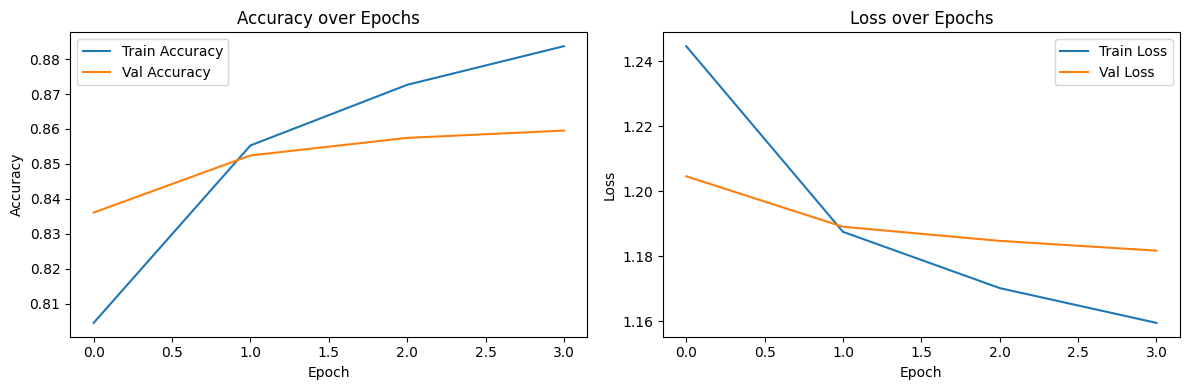

In [15]:
# Convert tensors to float for plotting
train_acc = [x.item() if hasattr(x, 'item') else x for x in history['train_acc']]
val_acc = [x.item() if hasattr(x, 'item') else x for x in history['val_acc']]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Cell 12: Confusion Matrix
Shows how well the model classifies each category

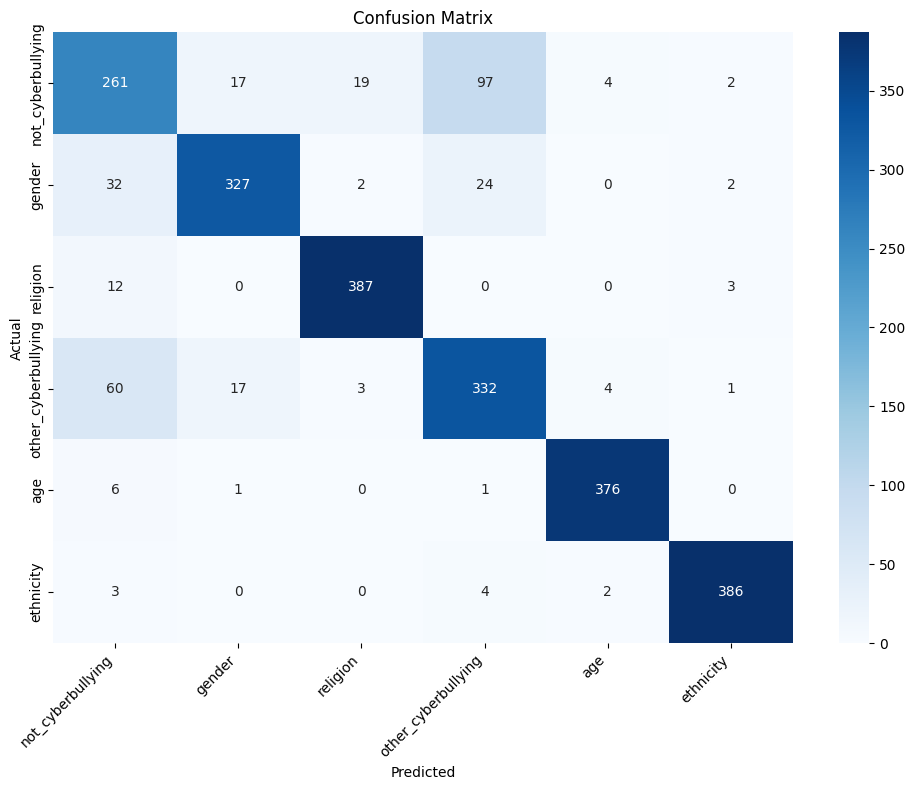


Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying       0.70      0.65      0.67       400
             gender       0.90      0.84      0.87       387
           religion       0.94      0.96      0.95       402
other_cyberbullying       0.72      0.80      0.76       417
                age       0.97      0.98      0.98       384
          ethnicity       0.98      0.98      0.98       395

           accuracy                           0.87      2385
          macro avg       0.87      0.87      0.87      2385
       weighted avg       0.87      0.87      0.87      2385



In [17]:
def get_predictions(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for d in data_loader:
            input_ids = d['input_ids'].to(device)
            attention_mask = d['attention_mask'].to(device)
            targets = d['targets'].to(device)
            emoji_vectors = d['emoji_vector'].to(device)      # ADD THIS
            sarcasm_scores = d['sarcasm_score'].to(device)    # ADD THIS

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                emoji_vectors=emoji_vectors,                  # ADD THIS
                sarcasm_scores=sarcasm_scores                 # ADD THIS
            )
            _, preds = torch.max(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)

preds, labels = get_predictions(model, test_data_loader)

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(labels, preds, target_names=class_names))

## Cell 13: classify_text extracts and uses sarcasm score
Test the model on your own sentences

In [18]:
def classify_text(text):
    original_text = text
    processed = process_text(text)

    emojis = [e['emoji'] for e in emoji.emoji_list(str(original_text))]
    emoji_vec = get_emoji_vector(emojis, e2v)
    emoji_tensor = torch.tensor(emoji_vec, dtype=torch.float).unsqueeze(0).to(device)

    sarcasm_score = get_sarcasm_score(original_text)  # ADD THIS
    sarcasm_tensor = torch.tensor([sarcasm_score], dtype=torch.float).to(device)

    encoding = tokenizer(
        processed,
        add_special_tokens=True,
        max_length=128,
        return_token_type_ids=False,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt',
    )
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        output = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            emoji_vectors=emoji_tensor,
            sarcasm_scores=sarcasm_tensor  # ADD THIS
        )
    _, prediction = torch.max(output, dim=1)
    label = class_names[prediction.item()]
    confidence = output[0][prediction.item()].item()
    return label, confidence, round(sarcasm_score, 3)  # also return sarcasm score

# Test sentences
test_sentences = [
    "Oh yeah, bullying people because of their religion is SO cool 🕌",
    "Have a great day everyone! 😊🎉",
    "People of that race are all the same 🤮",
    "Yeah right, like your age makes you so wise 👴",
    "Your gender makes you worthless 🤡",
]

print("=" * 60)
for sentence in test_sentences:
    label, confidence, sarcasm = classify_text(sentence)
    print(f"Text:       {sentence}")
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.2%}")
    print(f"Sarcasm:    {sarcasm:.3f}")
    print("-" * 60)

Text:       Oh yeah, bullying people because of their religion is SO cool 🕌
Prediction: not_cyberbullying
Confidence: 99.79%
Sarcasm:    0.016
------------------------------------------------------------
Text:       Have a great day everyone! 😊🎉
Prediction: not_cyberbullying
Confidence: 100.00%
Sarcasm:    0.094
------------------------------------------------------------
Text:       People of that race are all the same 🤮
Prediction: not_cyberbullying
Confidence: 64.91%
Sarcasm:    0.436
------------------------------------------------------------
Text:       Yeah right, like your age makes you so wise 👴
Prediction: not_cyberbullying
Confidence: 100.00%
Sarcasm:    0.119
------------------------------------------------------------
Text:       Your gender makes you worthless 🤡
Prediction: other_cyberbullying
Confidence: 95.02%
Sarcasm:    0.319
------------------------------------------------------------
